In [120]:
# !pip install qiskit==1.3.1
# !pip install qiskit-algorithms
from qiskit import QuantumCircuit, transpile
import numpy as np
from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.visualization import array_to_latex
from scipy.io import savemat
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

# 2-D XY Model Hamiltonian
$H_{XY} = \sum_{<i,j>}g_{ij}\frac{(\hat{X_i}\hat{X_j} + \hat{Y_i}\hat{Y_j})}{2} + \sum_i\omega_i\hat{Z_i}$

A 4-qubit $2\times2$ lattice with nearest-neighbor connections ($g_{ij}$) and on-site potentials ($\omega_i$) is used in this example. The below cell can be converted into a function to generate arbitrary XY-Hamiltonians.

In [121]:
# Input the adjacency matrix for the coupling terms and on-site potentials 
# define coupling and J matrices

def g_w(lattice_size, gm, h, staggered):

    n_qubits = lattice_size**2

    # Create the adjacency matrix for a nxn lattice with:
    # 1. Nearest Neighbor Connections
    # 2. No Periodeic Boundaries

    g = np.zeros((n_qubits, n_qubits))
    for qi in range(n_qubits):
        # Each qubit has: 1. right neighbor 2. down neighbor
        # Right Neighbor-- rightmost colum has no right neighbor
        if qi+1<n_qubits:
            neighbor_right = qi+1
            if ((qi+1) % lattice_size) != 0:
                g[qi][neighbor_right] = gm
        # Down Neighbor-- last row has no down neighbor
        if qi+lattice_size < n_qubits:
            neighbor_down = qi+lattice_size
            if ((qi) / lattice_size) < n_qubits:
                g[qi][neighbor_down] = gm
    g = (g+g.T)/2

    # Local Potentials:
    w = h*np.ones(n_qubits)

    if staggered == True:
        for qi in range(n_qubits):
            if qi%2==1:
                w[qi] = -w[qi]
    # Generat MATLAB variables
    # Format file name with parameters
        filename = f"potentials/data_lat{lattice_size}_gm{gm}_h{h}_staggered.mat"
    else:
        filename = f"potentials/data_lat{lattice_size}_gm{gm}_h{h}.mat"

    # Save to .mat file with variable names g and w
    savemat(filename, {'G': g, 'W': w})

    return g, w, n_qubits

# test g_w
lattice_size = 3
gm = 1
h = 1.8
staggered = True
g, w, n_qubits = g_w(lattice_size=lattice_size, gm=gm, h=h, staggered=staggered)

print(f'n_qubits: {n_qubits}')
print(f'Coupling Matrix (g): \n{g}')
print(f'On-Site Potentials (w): \n{w}')

n_qubits: 9
Coupling Matrix (g): 
[[0.  0.5 0.  0.5 0.  0.  0.  0.  0. ]
 [0.5 0.  0.5 0.  0.5 0.  0.  0.  0. ]
 [0.  0.5 0.  0.  0.  0.5 0.  0.  0. ]
 [0.5 0.  0.  0.  0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0.  0.5 0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5 0.  0.  0.  0.5]
 [0.  0.  0.  0.5 0.  0.  0.  0.5 0. ]
 [0.  0.  0.  0.  0.5 0.  0.5 0.  0.5]
 [0.  0.  0.  0.  0.  0.5 0.  0.5 0. ]]
On-Site Potentials (w): 
[ 1.8 -1.8  1.8 -1.8  1.8 -1.8  1.8 -1.8  1.8]


## 1. Analog Unitaries
### Unitaries using Matrix Exponentiation
The XY-Hamiltonians can be directly implemented by tuning the coupling and the detuning terms directly in the hardware (ref: [Thermalization and Criticality on an Analog-Digital Quantum Simulator](https://arxiv.org/abs/2405.17385)). This notebook does not dive into the specific implementations of such an analog implementation. Still, it discusses a more simplified model by exponentiating the Hamiltonian to enable a comparison with a Trotterization-based Unitary implementation in QETU.

Sources of errors/noise in the analog implementation must be studied, modeled, and incorporated for a more detailed/fair comparison with the digital implementation. 

In [122]:
# Analog U: create H using SparsePauliOp objects

def H_xy(g,w):
    from qiskit.quantum_info import SparsePauliOp

    # Define Pauli Strings using the coupling matrix (g) and on-site potentials (w)
    n_qubits = len(g)

    # Use the g and w martices to figure out the Pauli Terms
    pauli_strings = []
    coeffs = []

    # Coupling:
    # For a g[i][j] != 0, qubits i and j are neighbours
    for i in range(n_qubits):
        for j in range(i,n_qubits):
            stringX = ''
            stringY = ''
            if g[i][j] != 0:
                for k in range(n_qubits):
                    if k == i:
                        stringX = 'X' + stringX
                        stringY = 'Y' + stringY
                    elif k == j:
                        stringX = 'X' + stringX
                        stringY = 'Y' + stringY
                    else:
                        stringX = 'I' + stringX
                        stringY = 'I' + stringY
                pauli_strings.append(stringX)
                coeffs.append(g[i][j])
                pauli_strings.append(stringY)
                coeffs.append(g[i][j])
                
    # On-Site potentials:
    # for a w[k] != 0, qubit k has a non-zero onsite potential
    for k in range(n_qubits):
        stringZ = ''
        if w[k] != 0:
            stringZ = ''
            for i in range(n_qubits):
                if i==k:
                    stringZ = 'Z' + stringZ
                else:
                    stringZ = 'I' + stringZ
            pauli_strings.append(stringZ)
            coeffs.append(w[k])

    # Create the SparsePauliOp Hamiltonian
    H = SparsePauliOp(pauli_strings, coeffs)

    print(f'Coefficients: \n{coeffs}\n')
    print(f'Terms in the XY Hamiltonian: \n{pauli_strings}')
    return H

H = H_xy(g, w)

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']


## Shift and Rescale H
The original $H_{XY}$ needs to be shifted such that its eigenvalues ($\lambda_i$) $\in (\eta, \pi - \eta)$

This is done to ensure that $cos(\frac{\lambda_i}{2})$ $\in (0,1)$ to ease the filter design.

In [123]:
# shift and rescale the H

def H_shift_rescale(H, eta):
    E, V = np.linalg.eig(H.to_matrix().real)

    delta = (np.max(E)-np.min(E))
    Emin = np.min(E)

    c1 = ((np.pi-2*eta)/delta).real # scaling
    c2 = (eta-Emin*c1).real # shift
    # print(f'Scaling factor (c1): {c1}')
    # print(f'Shift (c2): {c2}')

    # Create the n x n identity matrix
    In = np.eye(2**n_qubits)

    # shift and rescale the H
    H_sim = c1*H.to_matrix().real + c2*In

    # print the shifted eigenvals
    E_sim = np.linalg.eig(H_sim)[0]
    # print(f"Max E: {np.max(E_sim)}")
    # print(f"Min E: {np.min(E_sim)}")
    E_sim, V_sim = np.linalg.eig(H_sim)

    for pos in range(len(E_sim)):
        if min(E_sim) == E_sim[pos]:
            idx = pos
    # print(idx)
    gs_arr = V_sim[:,idx]
    gs = Statevector(gs_arr)

    
    return c1, c2, gs_arr, gs

eta = 0.1
print(f"eta: {eta}")
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

print(f'Scaling Factor (c1): {c1}')
print(f'Shift (c2): {c2}')

# the gs vector
print('Ground State Vector:')
gs.draw('latex')

eta: 0.1


Scaling Factor (c1): 0.08274848791745125
Shift (c2): 1.5707963267948986
Ground State Vector:


<IPython.core.display.Latex object>

## Z-Rotations for shifting the Hamiltonian (Unitary)

Pauli strings anti-commute with H, but not with I, therefore:

$$K(c_1H + c_2I)K = c_1KHK + c_2KIK$$
$$= -c_1H + c_2$$

However, we need $-c_1H - c_2I$ to generate $U^{\dagger}$. Therefore, we can't directly use $K H_{sim} K$ to create time-reversal. $U^{\dagger}$ can be written as:
$$\ket{0}\bra{0} \otimes e^{(i\frac{c_1H}{2} + i\frac{c_2I}{2})} + \ket{1}\bra{1} \otimes e^{(-i\frac{c_1H}{2} - i\frac{c_2I}{2})}$$
$$= (\ket{0}\bra{0} \otimes e^{i\frac{c_1H}{2}} + \ket{1}\bra{1} \otimes e^{-i\frac{c_1H}{2}})(\ket{0}\bra{0} \otimes e^{+i\frac{c_2I}{2}} + \ket{1}\bra{1} \otimes e^{-i\frac{c_2I}{2}})$$
$$= (\ket{0}\bra{0} \otimes e^{ic_1H/2} + \ket{1}\bra{1} \otimes e^{-ic_1H/2})e^{-i\frac{c_2}{2}\hat{Z}}$$

Therefore, the shift in $H$ can be enabled in the corresponding unitary by using a $Z$-rotation. 

We use the following relations to create $cU$ and $cU^{\dagger}$ using $cK$:
$$cU^{\dagger} = cKUcK$$
$$\hat{X}cU^{\dagger}\hat{X} = cU$$

In [124]:
# Create the U with c1*H and add an extra Z-rotation (later) to shift c1*H by c2 
from qiskit.circuit.library import UnitaryGate

def Ua(c1, H):
    # Scale the original H matrix
    H_scaled = c1*H.to_matrix()
    
    # Create the corresponding Unitary Gate U(c1/2)
    U_scaled = expm(-1.j*H_scaled/2)
    Uc1_g = UnitaryGate(U_scaled, label="Ua(c1/2)")
    return Uc1_g

## 2. Digital Unitaries
### Unitaries using First-Order Trotterization

Create $e^{-ic_1H/2}$ using $I$-Order Trotterization

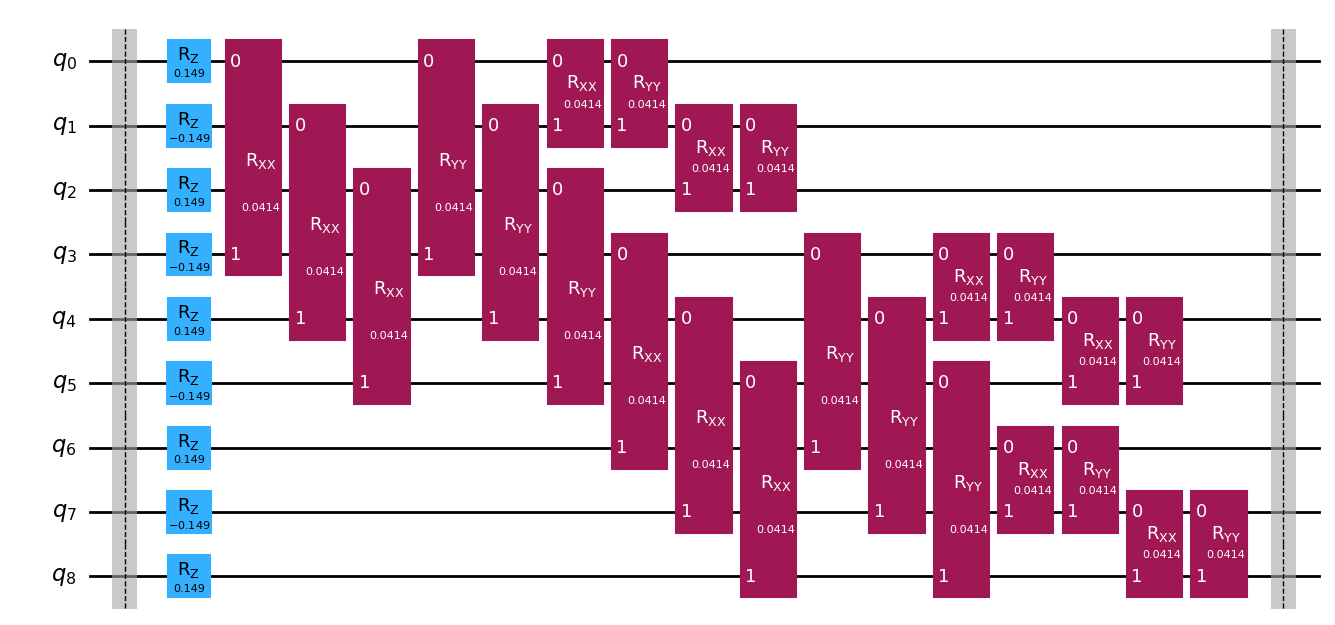

In [125]:
# Function to create the Trotterized circuit of the Hamiltonian
# Create Hamiltonian groupings in the 2-D spin grid, s.t. different gates on the same qubit are avoided
# For N = 9:

#    O === O --- O
#   ||    ||    ||
#   O === O --- O
#   |     |     |
#   O === O --- O

# the groupings for the XX and YY interactions would be H(1):"==="; H(2) "---"; H(3): "||"; H(4): "|"

# define a function to generate groupings
def find_groups(lattice_size):
    # List to store groups of nearest neighbors
    groups = [[], [], [], []]
    
    # Iterate over all lattice points
    for x in range(lattice_size):
        for y in range(lattice_size):
            # Determine the parity of x and y
            parity_x = x % 2
            parity_y = y % 2
            
            # Find the right neighboring points (right and up)
            if x + 1 < lattice_size:  # Right neighbor
                if  parity_x == 0:
                    groups[0].append([x*lattice_size+y, (x+1)*lattice_size+y])
                else:
                    groups[1].append([x*lattice_size+y, (x+1)*lattice_size+y])
            
            if y+1 < lattice_size:  # Up neighbor
                if parity_y == 0:
                    groups[2].append([x*lattice_size+y, x*lattice_size+y+1])
                else:
                    groups[3].append([x*lattice_size+y, x*lattice_size+y+1])
    
    # Return the groups ordered by your specified parity rule
    return groups


# generate 1st order trotterization
# U = (U1^(t/M)*U2^(t/M))^M

def Trotter(M, t, g, J, c1, num_qubits):
    qc_trot = QuantumCircuit(num_qubits)
    qc_trot.name = "Ut(c1/2)"
    # For every trotter step
    for steps in range(0,M):
        qc_trot.barrier()
        qc_trot_iter = QuantumCircuit(num_qubits) # qc for every step
        
        # Apply z rotations: rotation angle (including scaling) = -2*(t/M)*c1*J(i)
        for q in range(num_qubits):
            qc_trot_iter.rz(2*(t/M)*c1*J[q], q)
        
        # Apply XX and YY gates
        h_groups = find_groups(int(np.sqrt(num_qubits)))
        # print(np.sqrt(num_qubits))
        
        # for every group apply XX and YY gates on the qubits pairs (including scaling)
        for g_index in range(4):
            if h_groups[g_index] == []:
                continue
            else:
                for pairs in range(0,len(h_groups[g_index])):
                    qi = h_groups[g_index][pairs][0]
                    qj = h_groups[g_index][pairs][1]
                    qc_trot_iter.rxx(2*(t/M)*c1*g[qi][qj], qi, qj)
                    qc_trot_iter.ryy(2*(t/M)*c1*g[qi][qj], qi, qj)
                    
        qc_trot.append(qc_trot_iter, range(num_qubits))
    qc_trot.barrier()
    return qc_trot

# Create the Trotterized Circuit:

M = 1 # time steps
t = 0.5 # time of evolution (0.5 units of time for W(1/2))
qc_trot = QuantumCircuit(n_qubits)

qc_trot.append(Trotter(M,t,g,w,c1,n_qubits), range(n_qubits))
qc_trot.decompose(reps=2).decompose("disentangler_dg").decompose("multiplex1_reverse_dg").draw(output="mpl")

## Controlled Pauli Strings for c-U 

A "chessboard patterned" Pauli string would follow the anti-commutation condition. Black squares are $\hat{X}$, and white squares are $\hat{Y}$.
Switching $\hat{X}$ with $\hat{Y}$ should also do.

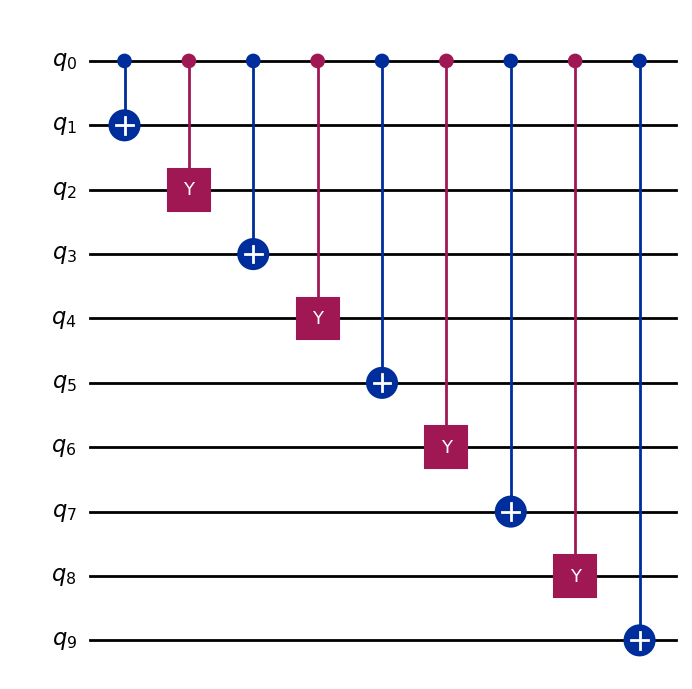

In [126]:
# Create Pauli Strings

def cPauli(n_qubits):
    num_qubits = n_qubits+1 # add the control qubit
    # create a quantum circuit
    qc_cK = QuantumCircuit(num_qubits, name="cK")
    # for qubit index (i,j), cx, if i+j is odd, else cy
    lattice_size = int(np.sqrt(num_qubits-1))
    for qi in range(num_qubits-1):
        i = int(qi/lattice_size)
        j = qi%lattice_size
        flag = i+j
        if flag%2==0:
            qc_cK.cx(0,qi+1)
        else:
            qc_cK.cy(0,qi+1)

    return qc_cK

# Test the controlled-Pauli function
ck = cPauli(n_qubits)
ck.draw(output="mpl", fold =-1)

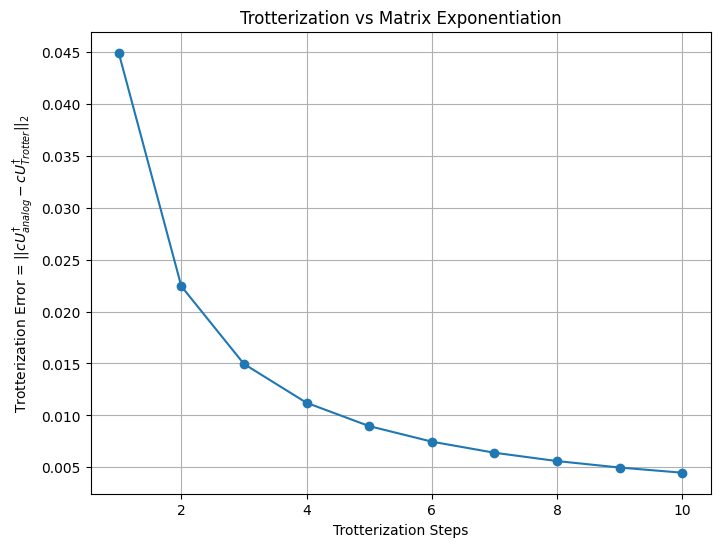

Norm2 of (cU_analog - cU_trotter) vs time-steps: 
[0.04490502 0.02243305 0.01495296 0.01121409 0.00897104 0.00747576
 0.00640774 0.00560674 0.00498375 0.00448536]


In [127]:
# Compare Trotterized cU_dagger and Analog cU_dagger
n_sim_qubits = n_qubits + 1

max_steps = 10
norm2 = np.zeros(max_steps)

for i in range(max_steps):
    # Trotterized cU_dagger
    qc_Ut = QuantumCircuit(n_sim_qubits)
    
    # time steps
    M = i+1
    t = 0.5
    
    # 1. Apply cK
    qc_Ut.append(cPauli(n_qubits), range(n_sim_qubits))
    # 2. Apply Ut
    qc_Ut.append(Trotter(M,t,g,w,c1,n_qubits), range(1,n_sim_qubits))
    # 3. Apply cK
    qc_Ut.append(cPauli(n_qubits), range(n_sim_qubits))
    
    # qc_Ut.draw('mpl')
    Ut_mat = Operator(qc_Ut).data
    
    # Analog cU_dagger
    Ua_g = Ua(c1, H)
    qc_Ua = QuantumCircuit(n_sim_qubits)
    
    qc_Ua.append(cPauli(n_qubits), range(n_sim_qubits))
    qc_Ua.append(Ua_g, range(1,n_sim_qubits))
    qc_Ua.append(cPauli(n_qubits),range(n_sim_qubits))
    
    Ua_mat = Operator(qc_Ua).data
    
    diff = Ua_mat - Ut_mat
    norm2[i] = np.linalg.norm(diff, ord = 2)

# Plot Errors vs Steps
# Create x-axis values (1 to max_steps)
x = np.arange(1, max_steps + 1)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, norm2, marker='o', linestyle='-')

# Set the title and labels
plt.title("Trotterization vs Matrix Exponentiation")
plt.xlabel("Trotterization Steps")
plt.ylabel("Trotterization Error = $||cU^{\dagger}_{analog}-cU^{\dagger}_{Trotter}||_2$")

# Optionally, add grid for clarity
plt.grid(True)

# Display the plot
plt.show()

print(f'Norm2 of (cU_analog - cU_trotter) vs time-steps: \n{norm2}')

In [128]:
# Automate loading phases
def phase_file(n_qubits, gm, w, d, staggered=False, shift=False):
    middle = f"g{gm}j{w}"
    if staggered:
        middle += "_staggered"
    if shift:
        middle = middle + "_shift"
    return f"phases/n{n_qubits}/{middle}/phases_{d}_new.txt"

p = phase_file(9,1,1.8,80,True,True)
print(f"file path: {p}")

file path: phases/n9/g1j1.8_staggered_shift/phases_80_new.txt


### Create the QETU Circuit

In [133]:
# create the initial state

def QETU(n_sim_qubits, phases, c1, c2, H, analog = False, digital = False, M = 1, state_init_amps = None):
    # initialize a quantum circuit with n_sim_qubit quantum registers and 1 classical register 
    qc = QuantumCircuit(n_sim_qubits, 1)
    
    # prepare the initial state
    if state_init_amps is None:
        # apply the hadamard gate to prepare and equiprobable state (in the H subspace only)
        for qi in range(1,n_sim_qubits):
            qc.h(qi)
    else:
        qc.initialize(state_init_amps, range(1,n_sim_qubits))
    qc.barrier()
    state_init = Statevector.from_instruction(qc)
    
    # create the QETU circuit
    
    # Create the analog Unitary
    if analog == True:
        Uc1_g = Ua(c1, H)
    
    # Enter the parameters for Trotterization
    elif digital == True:
        # M = 1
        t = 0.5
    
    stage = 0
    for p in phases:
        qc.rx(-2*p,0)
        stage += 1
        if stage != len(phases):
            if stage%2 == 1:
                # Apply cU:
                # 1. flip the ancilla
                qc.x(0)
                # 2. Z-rotation to shift c1*H
                qc.rz(c2,0)
                # 3. cK U(c1/2) cK = cU_dagger(c1/2)
                qc.append(cPauli(n_qubits), range(n_sim_qubits))
                if analog == True:
                    qc.append(Uc1_g, range(1,n_sim_qubits))
                elif digital == True:
                    qc.append(Trotter(M,t,g,w,c1,n_qubits), range(1,n_sim_qubits))
                qc.append(cPauli(n_qubits), range(n_sim_qubits))
                # 4. flip the ancilla back
                qc.x(0)
            else:
                # Apply cU_dagger:
                # 1. Z-rotation to shift c1*H
                qc.rz(c2,0)
                # 2. cK U(c1/2) cK = cU_dagger(c1/2)
                qc.append(cPauli(n_qubits), range(n_sim_qubits))
                if analog == True:
                    qc.append(Uc1_g, range(1,n_sim_qubits))
                elif digital == True:
                    qc.append(Trotter(M,t,g,w,c1,n_qubits), range(1,n_sim_qubits))
                qc.append(cPauli(n_qubits),range(n_sim_qubits))
    return qc, state_init


In [134]:
# Function for initial state preparation 
# (don't get too excited, this function just creates an array through dumb ways. This is not some smart oracle)

def initial_state(gs_arr, gamma):
    # 1. Create an equiprobable state
    eq_st = 1/(2**(n_qubits/2))*np.ones(2**n_qubits)
    eq_v = Statevector(eq_st)
    # eq_v.draw('latex')

    # 2. Calculate gs_perp
    eq_dot_gs = np.vdot(eq_st, gs_arr)*gs_arr # comp along gs
    gs_perp = eq_st - eq_dot_gs
    norm = np.linalg.norm(gs_perp,ord=2)
    gs_perp = (1/norm)*gs_perp

    # 3. prepare initial state w/ an overlap of gamma
    # gamma = 0.8
    in_st_arr = gamma*gs_arr + np.sqrt(1-gamma**2)*gs_perp
    return in_st_arr
    # print(np.vdot(gs_arr, in_st_arr))

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']


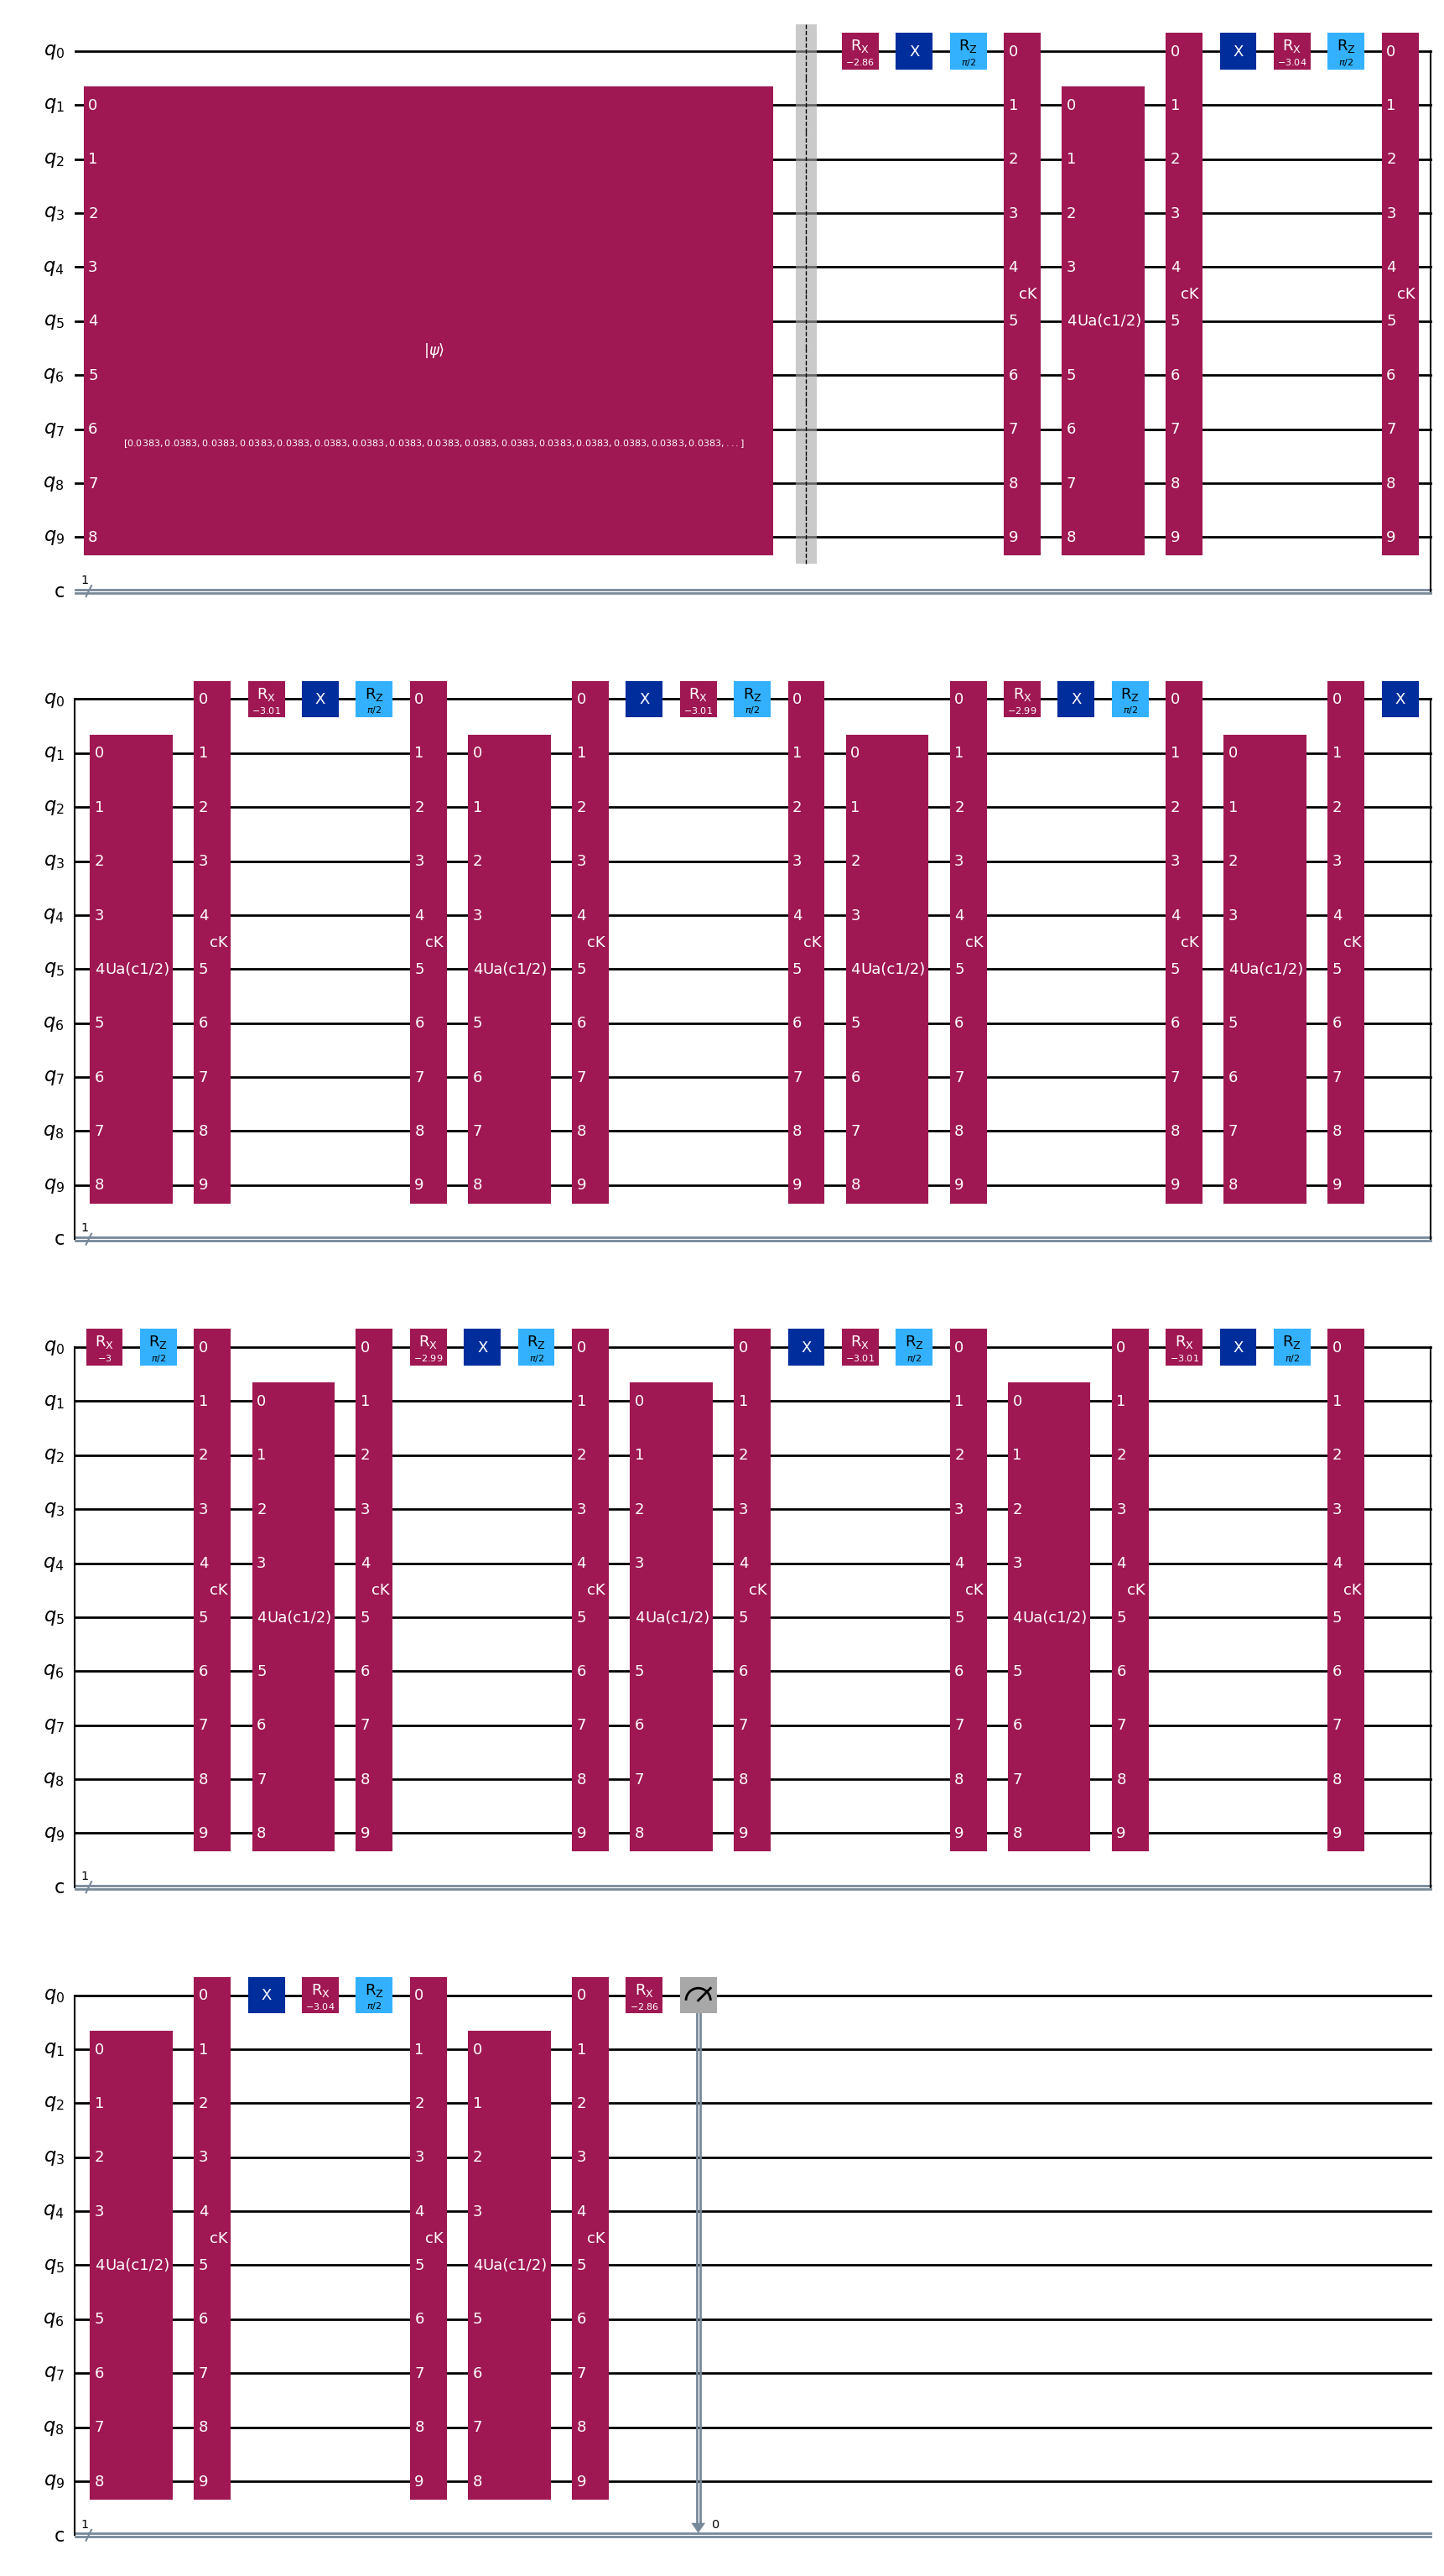

In [131]:
# Test QETU

# 1. Values of gm and h
lattice_size = 3
gm = 1
h = 1.8
staggered = True
degree = 10

# 2. Create the adjacency matrix
g, w, n_qubits = g_w(lattice_size, gm, h, staggered)
n_sim_qubits = n_qubits + 1

# 3. Create H for the XY Model
H = H_xy(g, w)

# 4. Shift and rescale
eta = 0.1
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

# 5. Load the phases (for the diagram to be small, choose the smallest filter size)
phase_path = phase_file(n_qubits, gm, h, degree, staggered)
phases_su2 = np.loadtxt(phase_path)
# 5.a: Convert them to X-rotations
phases  = phases_su2 + np.pi/2
phases[0] = phases[0] - np.pi/4
phases[-1] = phases[-1] - np.pi/4

# choose bw analog/ digital implementations
analog = True
digital = False
M = 3 # no. of Trotter Steps

# 6. Prepare the initial state: <gs_true|gs_est> = gamma
gamma = 0.5
amp_sys = initial_state(gs_arr, gamma)

# create the QETU circuit
qc, state_in = QETU(n_sim_qubits, phases, c1, c2, H, analog, digital, M, amp_sys)
# measure qubit 0 and store it in the classical register
qc.measure(0,0)

qc.draw('mpl')

In [132]:
# State fidelity (d = 20)
d = 14
phase_path = phase_file(n_qubits, gm, h, d, staggered)
phases_su2 = np.loadtxt(phase_path)
# 5.a: Convert them to X-rotations
phases  = phases_su2 + np.pi/2
phases[0] = phases[0] - np.pi/4
phases[-1] = phases[-1] - np.pi/4

state = Statevector.from_instruction(QETU(n_sim_qubits, phases, c1, c2, H, True, False, M, amp_sys)[0])
substate_data = state.data[0::2]

# Create a new Statevector object from the extracted amplitudes
substate = Statevector(substate_data)

# Normalize the substate (to emulate a '0' measurement on the ancilla)
norm_substate = Statevector(substate / np.linalg.norm(substate))

# Calculate the overlap and fidelity
target = Statevector(gs_arr)

# Calculate the overlap
overlap = norm_substate.inner(target).real
fidelity = (abs(overlap))**2
print(f"Overlap: {overlap}")
print(f"State Fidelity: {fidelity}")
print('Final State from QETU:')
norm_substate.draw('latex')

Overlap: -0.9832218525784909
State Fidelity: 0.9667252113878797
Final State from QETU:


<IPython.core.display.Latex object>

## State Fidelity vs Polynomial Degree

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']
State Fidelity: 0.6506981130202883
State Fidelity: 0.8722594817116793
State Fidelity: 0.9667252113878797
State Fidelity: 0.9855054868645078
State Fidelity: 0.9946768465963577
State Fidelity: 0.9941455535149577
State Fidelity: 0.9965539640156883


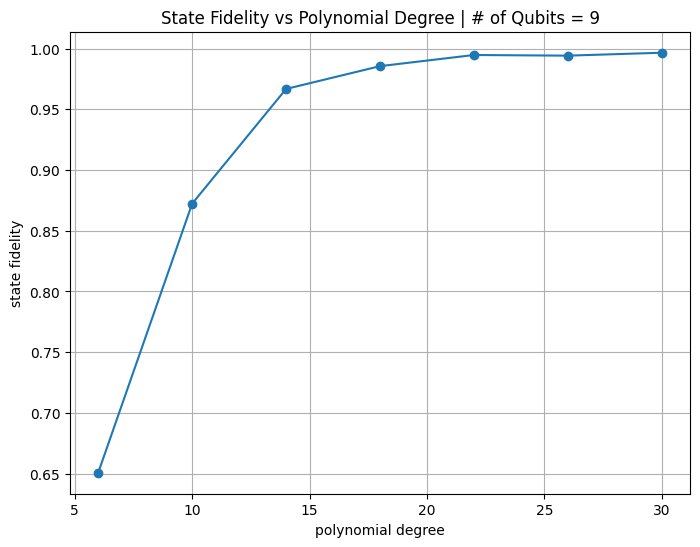

In [135]:
# 1. Values of gm and h
lattice_size = 3
gm = 1
h = 1.8
staggered = True

# polynomial degree to be used for filter design
degrees = [6, 10, 14, 18, 22, 26, 30]

# 2. Create the adjacency matrix
g, w, n_qubits = g_w(lattice_size, gm, h, staggered)
n_sim_qubits = n_qubits + 1

# 3. Create H for the XY Model
H = H_xy(g, w)

# 4. Shift and rescale
eta = 0.1
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

# 5. Prepare the initial state with overlap gamma
gamma = 0.5
amp_sys = initial_state(gs_arr, gamma)

overlaps = []
fidelities = []

idx = 0
for d in degrees:
    # 6. Load the phases
    p = phase_file(n_qubits, gm, h, d, staggered)
    phases_su2 = np.loadtxt(p)
    # Convert them to X-rotations
    phases  = phases_su2 + np.pi/2
    phases[0] = phases[0] - np.pi/4
    phases[-1] = phases[-1] - np.pi/4

    # 7. QETU
    state = Statevector.from_instruction(QETU(n_sim_qubits, phases, c1, c2, H, True, False, M, amp_sys)[0])
    substate_data = state.data[0::2]

    # Create a new Statevector object from the extracted amplitudes
    substate = Statevector(substate_data)

    # Normalize the substate (to emulate a '0' measurement on the ancilla)
    norm_substate = Statevector(substate / np.linalg.norm(substate))

    # Calculate the overlap and fidelity
    target = Statevector(gs_arr)

    # Calculate the overlap
    overlaps.append(norm_substate.inner(target).real)
    fidelities.append((abs(overlaps[idx]))**2)
    # print(f"Overlap: {ov[run]}")
    print(f"State Fidelity: {fidelities[idx]}")
    idx = idx+1
    
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(degrees, fidelities, marker='o', linestyle='-')

# Set the title and labels
plt.title(f"State Fidelity vs Polynomial Degree | # of Qubits = {n_qubits}")
plt.xlabel("polynomial degree")
plt.ylabel("state fidelity")

# Add grid for clarity
plt.grid(True)

# Display the plot
plt.show()

## State Fidelity vs Trotter Steps

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']
State Fidelity: 0.9599398069999548
State Fidelity: 0.9648660633426621
State Fidelity: 0.9658278774871297
State Fidelity: 0.9661805921231454
State Fidelity: 0.9663511537375543
State Fidelity: 0.9664477432079787
State Fidelity: 0.9665083496889268
State Fidelity: 0.966549218032295
State Fidelity: 0.9665782864501947
State Fidelity: 0.9665998287525369


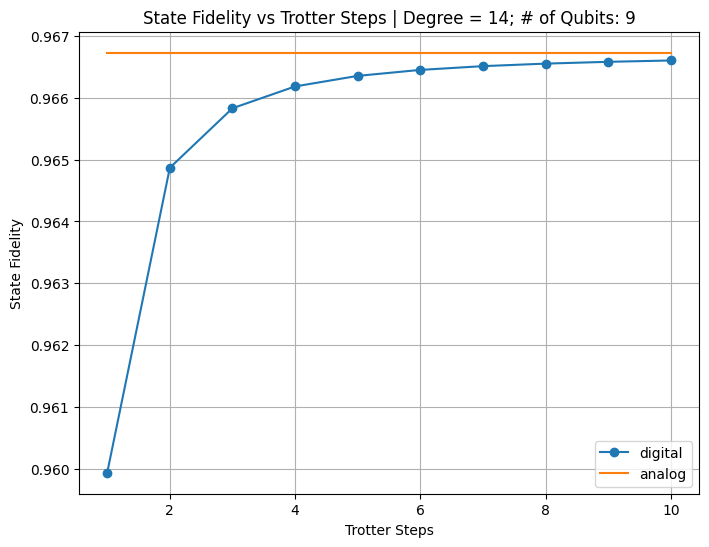

Theoretical Ground State:


<IPython.core.display.Latex object>

In [42]:
max_m = 10
ov = np.zeros(max_m)
fid = np.zeros(max_m)
run = 0

# 1. Values of gm and h
lattice_size = 3
gm = 1
h = 1.8
staggered = True

# 2. Create the adjacency matrix
g, w, n_qubits = g_w(lattice_size, gm, h, staggered)
n_sim_qubits = n_qubits + 1

# 3. Create H for the XY Model
H = H_xy(g, w)

# 4. Shift and rescale
eta = 0.1
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

# initial state with 0.5 overlap
gamma = 0.5
amp_sys = initial_state(gs_arr, gamma)

# polynomial degree to be used for filter design
d = 14

# load phases
p = phase_file(n_qubits, gm, h, d, staggered)
phases_su2 = np.loadtxt(p)
# Convert them to X-rotations
phases  = phases_su2 + np.pi/2
phases[0] = phases[0] - np.pi/4
phases[-1] = phases[-1] - np.pi/4

for M in range(1,max_m+1):

    state = Statevector.from_instruction(QETU(n_sim_qubits, phases, c1, c2, H, False, True, M, amp_sys)[0])
    substate_data = state.data[0::2]

    # Create a new Statevector object from the extracted amplitudes
    substate = Statevector(substate_data)

    # Normalize the substate (to emulate a '0' measurement on the ancilla)
    norm_substate = Statevector(substate / np.linalg.norm(substate))

    # Calculate the overlap and fidelity
    target = Statevector(gs_arr)

    # Calculate the overlap
    ov[run] = norm_substate.inner(target).real
    fid[run] = (abs(ov[run]))**2
    # print(f"Overlap: {ov[run]}")
    print(f"State Fidelity: {fid[run]}")
    run += 1

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(range(1,max_m+1), fid, marker='o', linestyle='-', label='digital')
plt.plot(range(1,max_m+1), fidelity*np.ones(max_m), linestyle='-', label='analog')

# Set the title and labels
plt.title(f"State Fidelity vs Trotter Steps | Degree = {d}; # of Qubits: {n_qubits}")
plt.xlabel("Trotter Steps")
plt.ylabel("State Fidelity")

# Add grid for clarity
plt.grid(True)
plt.legend()

# Display the plot
plt.show()

print(f'Theoretical Ground State:')
target.draw('latex')

### $P_{0}$ vs Initial Overlap ($\gamma$)


In [16]:
from qiskit.primitives import StatevectorSampler

# 1. Values of gm and h
lattice_size = 3
gm = 1
h = 1.8
staggered = True

# polynomial degree to be used for filter design
d = 30

# 2. Create the adjacency matrix
g, w, n_qubits = g_w(lattice_size, gm, h, staggered)
n_sim_qubits = n_qubits + 1

# 3. Create H for the XY Model
H = H_xy(g, w)

# 4. Shift and rescale
eta = 0.1
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

# Polynomial degrees to be used for QETU
degrees = [6, 10, 14, 18, 22, 26, 30]

# Initial state overlaps
gammas = np.linspace(0.5, 1, num=10)

p0 = np.zeros((len(degrees), len(gammas))) # to store the success probabilities

d_idx = 0
for d in degrees:
    # 5. Load the phases
    p = phase_file(n_qubits, gm, h, d, staggered)
    phases_su2 = np.loadtxt(p)
    # Convert them to X-rotations
    phases  = phases_su2 + np.pi/2
    phases[0] = phases[0] - np.pi/4
    phases[-1] = phases[-1] - np.pi/4

    gamma_idx = 0
    for gamma in gammas:
        amp_sys = initial_state(gs_arr, gamma)
        
        # create the QETU circuit
        qc, state_init = QETU(n_sim_qubits, phases, c1, c2, H, True, False, M, amp_sys)
        # measure qubit 0 and store it in the classical register
        qc.measure(0,0)

        # measure "shots" number of times
        qc_measured = qc.measure_all(inplace=False)

        # 3. Execute using the Sampler primitive
        sampler = StatevectorSampler()
        shots = 10000
        job = sampler.run([qc_measured], shots=shots)
        result = job.result()

        # calculate the probability of 0 measurement
        p0[d_idx][gamma_idx]=(result[0].data.c.get_counts()['0']/shots)
        gamma_idx += 1
    d_idx += 1

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']


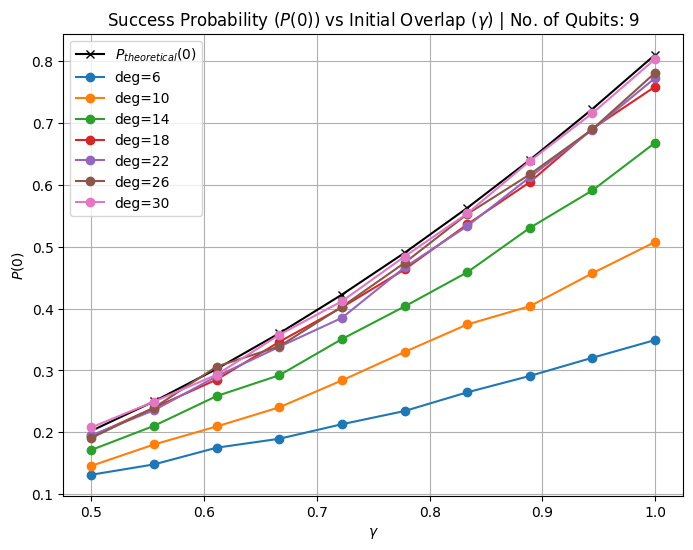

In [162]:
fmax = 0.90
p0_th = gammas**2*fmax**2

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(gammas, p0_th, marker='x', linestyle='-', label='$P_{theoretical}(0)$', color='black')
for d_idx in range(len(degrees)):
    plt.plot(gammas, p0[d_idx], marker='o', linestyle='-', label=f'deg={degrees[d_idx]}')

# Set the title and labels
plt.title(f"Success Probability ($P(0)$) vs Initial Overlap ($\gamma$) | No. of Qubits: {n_qubits}")
plt.xlabel("$\gamma$")
plt.ylabel("$P(0)$")

# Add grid for clarity
plt.grid(True)
plt.legend()

# Display the plot
plt.show()

There is a significant deviation in the trend for success probability vs initial overlap for $N=9$. This gap almost disappears for $N=4$ when corrected for imperfect $f_{max}$. 
Next Steps:
1. Re-derive the expression for $P(0)$ considering the non-idealities in the filter function design
2. Generate plots for lower depth filter for $N=4$

NOT ANYMORE!!

In [18]:
# Gate counts
# Noise
# Larger Lattices: Polynomial Degree vs Lattice Size for a fixed state fidelity (analog QETU)
# optimize your pauli string in terms of Clifford gate set

# The Goated Shift
ofc by yours truly 8 )  

In [143]:
g, w, n_qubits = g_w(lattice_size=3, gm=1, h=1.8, staggered=True)
H_old = H_xy(g, w)

# H --> -H
H_new = -H_old

# use the same function to shift and rescale H
E, V = np.linalg.eig(H_new.to_matrix().real)

print(f'E_max: {-np.min(E)}')
print(f'E_min: {-np.max(E)}')

eta = 0.1
k1, k2, not_gs_arr, not_gs = H_shift_rescale(H_new, eta)
not_k1, not_k2, gs_arr, gs = H_shift_rescale(H_old, eta)

# Since E_max and E_min are symmetric about the origin, c1 = k1 and c2 = k2
print(f'k1: {k1}; k2: {k2}')
print(f'c1: {c1}; c2: {c2}')


Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']


E_max: 17.774298525698107
E_min: -17.77429852569793
k1: 0.08274848791745139; k2: 1.5707963267949039
c1: 0.08274848791745125; c2: 1.5707963267948986


In [155]:
phase_path = phase_file(n_qubits, gm, h, degree, staggered)
phases_su2 = np.loadtxt("phases/n9/g1j1.8_staggered_shift/phases_30_new.txt")
# 5.a: Convert them to X-rotations
phases  = phases_su2 + np.pi/2
phases[0] = phases[0] - np.pi/4
phases[-1] = phases[-1] - np.pi/4

gamma = 0.5
amp_sys = initial_state(gs_arr, gamma)

qc_shift, state_shift = QETU(n_qubits+1, phases, c1, c2, H_new, True, False, 1, amp_sys)

# qc_shift.draw('mpl')
gs.draw('latex')

<IPython.core.display.Latex object>

In [156]:
# state = Statevector.from_instruction(QETU(n_sim_qubits, phases, k1, k2, H_old, True, False, M, amp_sys)[0])
state = Statevector.from_instruction(qc_shift)
substate_data = state.data[0::2]

# Create a new Statevector object from the extracted amplitudes
substate = Statevector(substate_data)

# Normalize the substate (to emulate a '0' measurement on the ancilla)
norm_substate = Statevector(substate / np.linalg.norm(substate))

# Calculate the overlap and fidelity
target = Statevector(gs_arr)

# Calculate the overlap
overlap = norm_substate.inner(target).real
fidelity = (abs(overlap))**2
print(f"Overlap: {overlap}")
print(f"State Fidelity: {fidelity}")
print('Final State from QETU:')
norm_substate.draw('latex')

Overlap: -0.9957592688710719
State Fidelity: 0.9915365215426517
Final State from QETU:


<IPython.core.display.Latex object>

Coefficients: 
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8, -1.8, 1.8]

Terms in the XY Hamiltonian: 
['IIIIIIIXX', 'IIIIIIIYY', 'IIIIIXIIX', 'IIIIIYIIY', 'IIIIIIXXI', 'IIIIIIYYI', 'IIIIXIIXI', 'IIIIYIIYI', 'IIIXIIXII', 'IIIYIIYII', 'IIIIXXIII', 'IIIIYYIII', 'IIXIIXIII', 'IIYIIYIII', 'IIIXXIIII', 'IIIYYIIII', 'IXIIXIIII', 'IYIIYIIII', 'XIIXIIIII', 'YIIYIIIII', 'IXXIIIIII', 'IYYIIIIII', 'XXIIIIIII', 'YYIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII']
State Fidelity: 0.6552724642409169
State Fidelity: 0.8766295534784118
State Fidelity: 0.9672662164615073
State Fidelity: 0.9544562431218555
State Fidelity: 0.9793284630503513
State Fidelity: 0.9823245776350764
State Fidelity: 0.9915365215426517


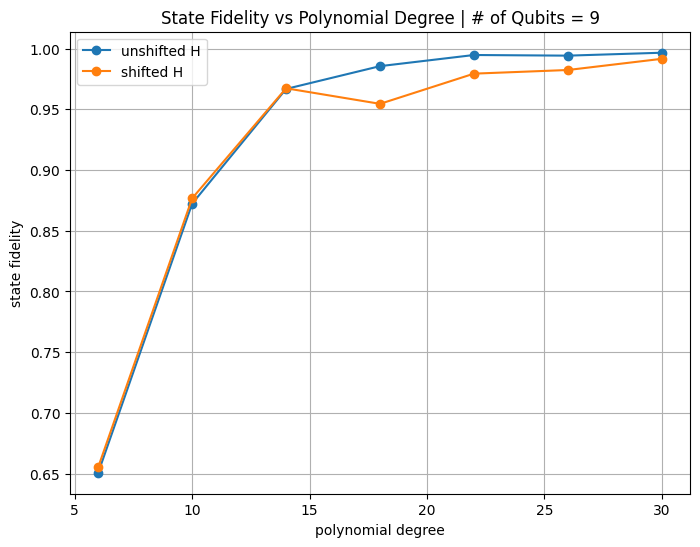

In [160]:
# 1. Values of gm and h
lattice_size = 3
gm = 1
h = 1.8
staggered = True
shift = True

# polynomial degree to be used for filter design
degrees = [6, 10, 14, 18, 22, 26, 30]

# 2. Create the adjacency matrix
g, w, n_qubits = g_w(lattice_size, gm, h, staggered)
n_sim_qubits = n_qubits + 1

# 3. Create H for the XY Model
H = H_xy(g, w)

# 4. Shift and rescale
eta = 0.1
c1, c2, gs_arr, gs = H_shift_rescale(H, eta)

# 5. Prepare the initial state with overlap gamma
gamma = 0.5
amp_sys = initial_state(gs_arr, gamma)

overlaps_shift = []
fidelities_shift = []

idx = 0
for d in degrees:
    # 6. Load the phases
    p = phase_file(n_qubits, gm, h, d, staggered, shift)
    phases_su2 = np.loadtxt(p)
    # Convert them to X-rotations
    phases  = phases_su2 + np.pi/2
    phases[0] = phases[0] - np.pi/4
    phases[-1] = phases[-1] - np.pi/4

    # 7. QETU
    state = Statevector.from_instruction(QETU(n_sim_qubits, phases, c1, c2, -H, True, False, M, amp_sys)[0])
    substate_data = state.data[0::2]

    # Create a new Statevector object from the extracted amplitudes
    substate = Statevector(substate_data)

    # Normalize the substate (to emulate a '0' measurement on the ancilla)
    norm_substate = Statevector(substate / np.linalg.norm(substate))

    # Calculate the overlap and fidelity
    target = Statevector(gs_arr)

    # Calculate the overlap
    overlaps_shift.append(norm_substate.inner(target).real)
    fidelities_shift.append((abs(overlaps_shift[idx]))**2)
    # print(f"Overlap: {ov[run]}")
    print(f"State Fidelity: {fidelities_shift[idx]}")
    idx = idx+1
    
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(degrees, fidelities, marker='o', linestyle='-', label='unshifted H')
plt.plot(degrees, fidelities_shift, marker='o', linestyle='-', label='shifted H')

# Set the title and labels
plt.title(f"State Fidelity vs Polynomial Degree | # of Qubits = {n_qubits}")
plt.xlabel("polynomial degree")
plt.ylabel("state fidelity")

# Add grid for clarity
plt.grid(True)
plt.legend()

# Display the plot
plt.show()